In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
#from scipy.stats import gaussian_kde




plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

In [ ]:
df2024 = pd.read_csv("/content/delitos_2024.csv")
df2023 = pd.read_csv("/content/delitos_2023.csv")


# INTRODUCCION

### En este trabajo se desarrolla un analisis exploratorio de datos utilizando un Jupyter Notebook como herramienta principal. A partir de un conjunto de datos provenientes de registros de delitos, se realiza un proceso completo de limpieza, estructuración, transformación y visualización con el objetivo de identificar patrones temporales y geográficos. El enfoque permite aplicar conceptos fundamentales de análisis de datos y mostrar cómo la exploración sistemática facilita la comprensión del comportamiento delictivo en la ciudad.


# FUENTE:

* Gobierno de la ciudad (https://data.buenosaires.gob.ar/dataset/delitos)




### Reviso que los dos Dataframes tengan la misma estructura

---



In [ ]:
df2023.info()== df2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155897 entries, 0 to 155896
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   id-mapa   155897 non-null  int64  
 1   anio      155897 non-null  int64  
 2   mes       155897 non-null  object 
 3   dia       155897 non-null  object 
 4   fecha     155897 non-null  object 
 5   franja    155897 non-null  int64  
 6   tipo      155897 non-null  object 
 7   subtipo   155897 non-null  object 
 8   uso_arma  155897 non-null  object 
 9   uso_moto  155897 non-null  object 
 10  barrio    152739 non-null  object 
 11  comuna    152739 non-null  float64
 12  latitud   155549 non-null  float64
 13  longitud  155549 non-null  float64
 14  cantidad  155897 non-null  int64  
dtypes: float64(3), int64(4), object(8)
memory usage: 17.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158838 entries, 0 to 158837
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dty

True

In [ ]:
df2023.sample()

,id-mapa,anio,mes,dia,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad
92537,1336252,2023,MARZO,LUNES,2023-03-20,2,Hurto,Hurto total,NO,NO,RECOLETA,2.0,-34.587854,-58.395291,1


### Concateno ambos DF en uno




In [ ]:
df1 = pd.concat([df2024,df2023],axis =0 , ignore_index = True)

In [ ]:
df = df1.copy()

In [ ]:
display(df.head())

,id-mapa,anio,mes,dia,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad
0,1399612,2024,ENERO,LUNES,2024-01-01,17.0,Robo,Robo total,SI,NO,CHACARITA,15.0,-34.585182,-58.453967,1
1,1399613,2024,ENERO,LUNES,2024-01-01,6.0,Robo,Robo total,SI,NO,CHACARITA,15.0,-34.584186,-58.453476,1
2,1399614,2024,ENERO,LUNES,2024-01-01,1.0,Hurto,Hurto total,NO,NO,MATADEROS,9.0,-34.664360,-58.502121,1
3,1399615,2024,ENERO,LUNES,2024-01-01,19.0,Robo,Robo total,NO,NO,PALERMO,14.0,-34.564851,-58.434855,1
4,1399616,2024,ENERO,LUNES,2024-01-01,20.0,Hurto,Hurto total,NO,NO,SAN NICOLAS,1.0,-34.605522,-58.391176,1


In [ ]:
len(df)

314735

### Exploro estructura, tipos de datos, cantidad de nulos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314735 entries, 0 to 314734
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   id-mapa   314735 non-null  int64  
 1   anio      314735 non-null  int64  
 2   mes       314735 non-null  object 
 3   dia       314735 non-null  object 
 4   fecha     314735 non-null  object 
 5   franja    314688 non-null  float64
 6   tipo      314735 non-null  object 
 7   subtipo   314735 non-null  object 
 8   uso_arma  314735 non-null  object 
 9   uso_moto  314735 non-null  object 
 10  barrio    307655 non-null  object 
 11  comuna    307655 non-null  float64
 12  latitud   310553 non-null  float64
 13  longitud  310553 non-null  float64
 14  cantidad  314735 non-null  int64  
dtypes: float64(4), int64(3), object(8)
memory usage: 36.0+ MB


In [ ]:
df.isna().sum()

,0
id-mapa,0
anio,0
mes,0
dia,0
fecha,0
franja,47
tipo,0
subtipo,0
uso_arma,0
uso_moto,0


## Tratamiento de nulos:
 Evaluo las columnas que tienen valores nulos y decido para este analisis.
 - Decido eliminar los registros que tengan nulo en latitud o longitud y los valores nulos en Franja.

 - Los valores nulos en barrio y comuna que no tengan nulos en latitud o longitud los mantendre porque no afectan a mi analisis posterior.

### Limpio nulos, duplicados y ajusto tipo de datos

In [ ]:
# Eliminar duplicados
df = df.drop_duplicates()


# Rellenar nulos en columnas categoricas
df['barrio'] = df['barrio'].fillna('SIN_DATOS')
df['comuna'] = df['comuna'].fillna('SIN_DATOS')
df['uso_arma'] = df['uso_arma'].map({'SI': 1, 'NO': 0})
df['uso_moto'] = df['uso_moto'].map({'SI': 1, 'NO': 0})


# Filtrar NaN en latitud o longitud nulos
df = df.dropna(subset=['latitud', 'longitud'])



# Convertir geo a float
df['latitud'] = df['latitud'].astype(float)
df['longitud'] = df['longitud'].astype(float)


# Filtrar coordenadas NO validas (por ejemplo fuera de CABA)
df = df[
    (df['latitud'] >= -34.71) &
    (df['latitud'] <= -34.5) &
    (df['longitud'] >= -58.54) &
    (df['longitud'] <= -58.29)
]



df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
df['dia_numero'] = df['fecha'].dt.weekday
df['anio_mes'] = df['fecha'].dt.to_period('M').astype('datetime64[ns]')
df = df.sort_values('fecha')

In [ ]:
# Filtrar NaN en franja
df = df.dropna(subset=['franja'])

In [ ]:
df.isna().sum()

,0
id-mapa,0
anio,0
mes,0
dia,0
fecha,0
franja,0
tipo,0
subtipo,0
uso_arma,0
uso_moto,0


In [ ]:
df['tipo'].value_counts()

,count
tipo,
Robo,133117
Hurto,125044
Vialidad,18490
Lesiones,16396
Amenazas,14410
Homicidios,168


## Creo una columna para indicar momento del dia segun franja horaria

In [ ]:
def clasificar_momento(hora):
    if 6 <= hora < 12:
        return "Mañana"
    elif 12 <= hora < 18:
        return "Tarde"
    elif 18 <= hora < 24:
        return "Noche"
    else:
        return "Madrugada"

df['momento_del_dia'] = df['franja'].astype(float).apply(clasificar_momento)

orden_momentos = ["Mañana", "Tarde", "Noche", "Madrugada"]
df['momento_del_dia'] = pd.Categorical(
    df['momento_del_dia'],
    categories=orden_momentos,
    ordered=True
)

## **Graficos**

## Evolución de cantidad de delitos por mes


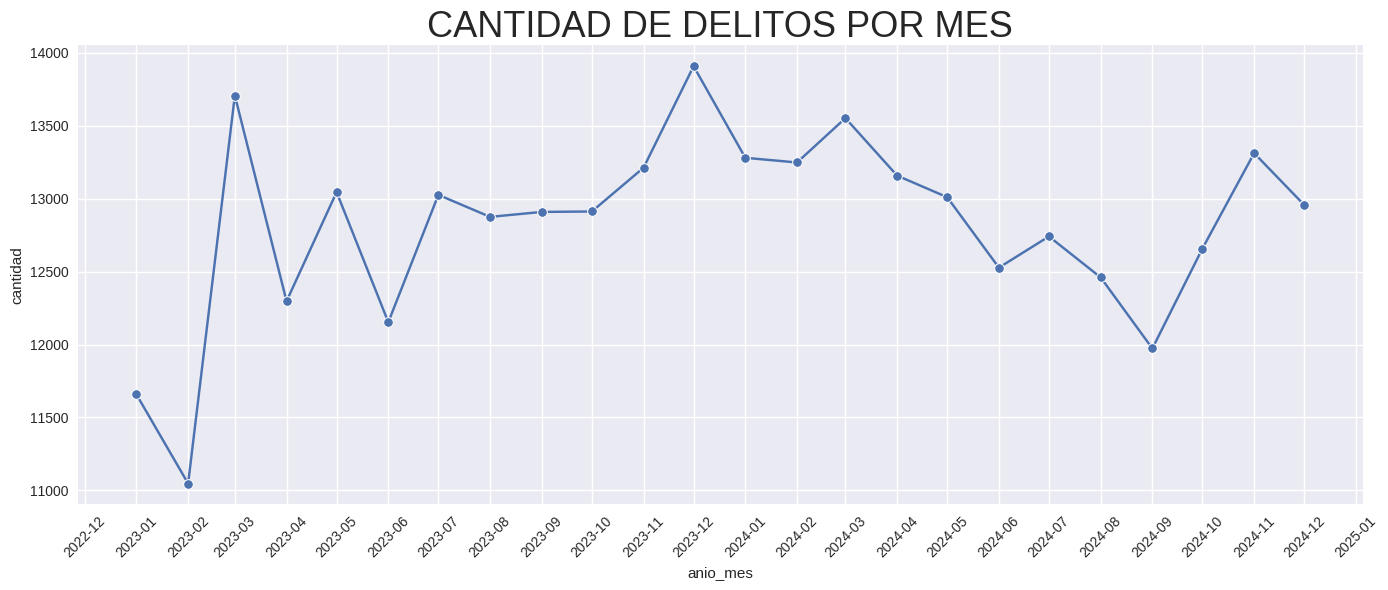

In [ ]:
# Agrupar
delitos_mensuales = df.groupby('anio_mes')['cantidad'].sum().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(
    data=delitos_mensuales,
    x='anio_mes',
    y='cantidad',
    marker='o'
)
plt.title("CANTIDAD DE DELITOS POR MES", fontsize=26)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())   # 1 tick por mes
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Detalle por día de la semana y momento del día

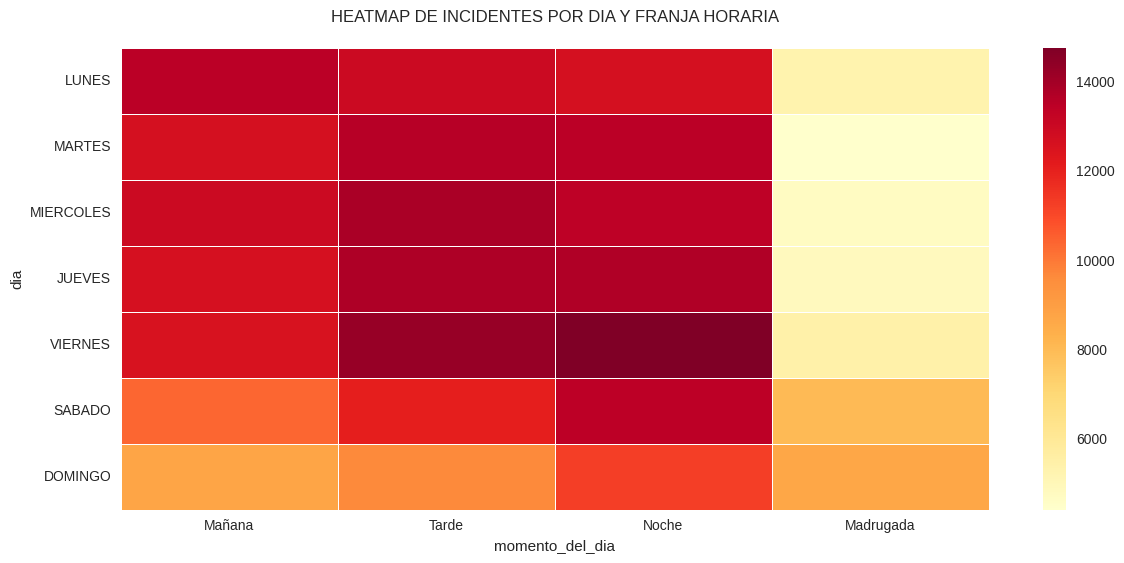

In [ ]:
pivot = df.pivot_table(values='cantidad', index='dia', columns='momento_del_dia', aggfunc='sum',observed=False)
orden = df[['dia','dia_numero']].drop_duplicates().set_index('dia')['dia_numero']


pivot = pivot.loc[orden.sort_values().index]

plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=.5)
plt.title(f'HEATMAP DE INCIDENTES POR DIA Y FRANJA HORARIA\n')
plt.show()

### Detalle por hora y momento del día

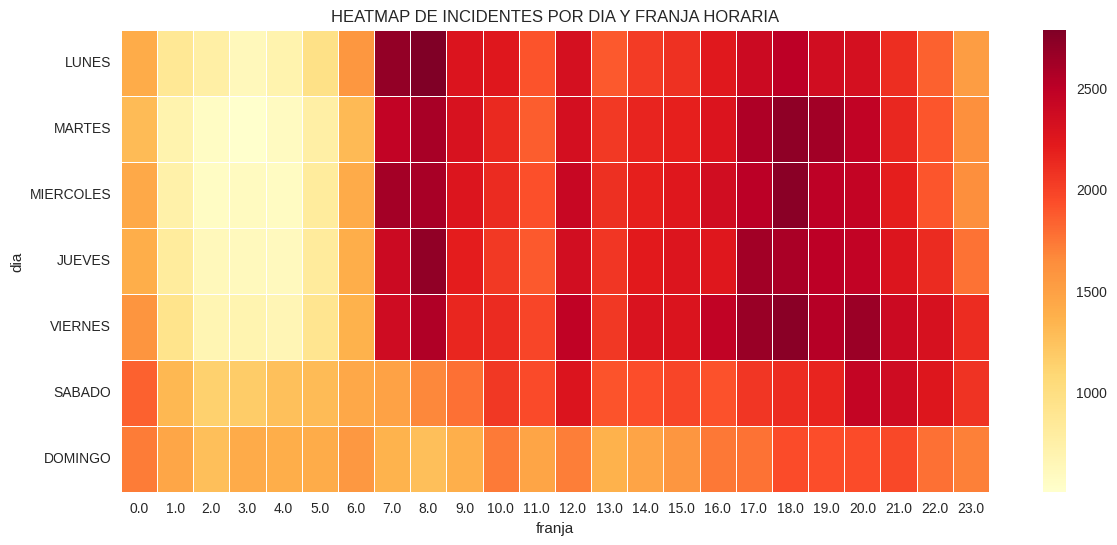

In [ ]:
pivot = df.pivot_table(values='cantidad', index='dia', columns='franja', aggfunc='sum')
orden = df[['dia','dia_numero']].drop_duplicates().set_index('dia')['dia_numero']


pivot = pivot.loc[orden.sort_values().index]

plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=.5)
plt.title('HEATMAP DE INCIDENTES POR DIA Y FRANJA HORARIA')
plt.show()

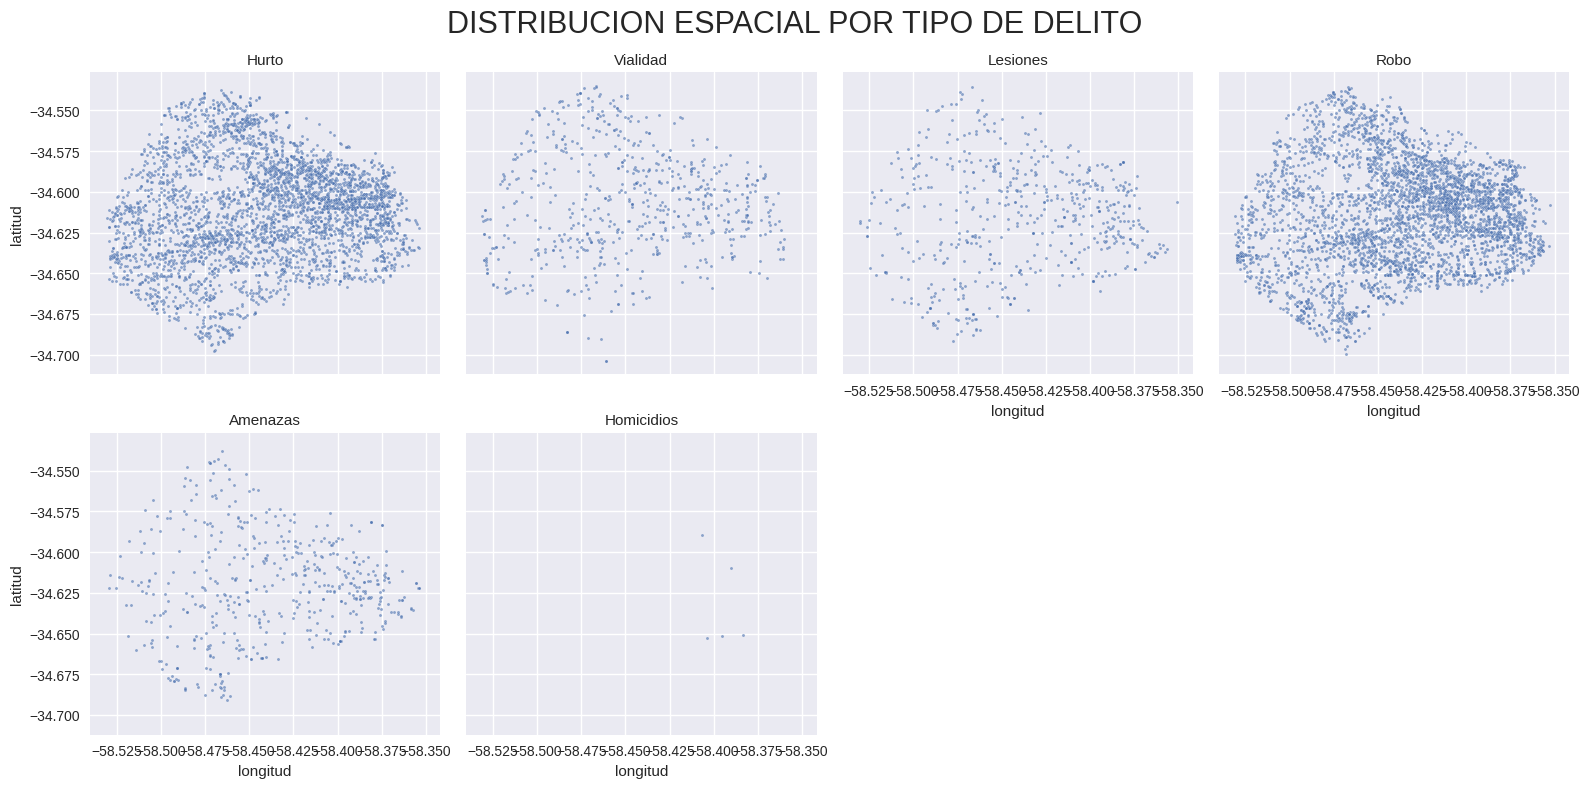

In [ ]:
g = sns.FacetGrid(
    df.sample(10000),
    col="tipo",
    col_wrap=4,
    height=4
)

g.map_dataframe(sns.scatterplot, x="longitud", y="latitud", s=5, alpha=0.6)
g.set_titles(col_template="{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("DISTRIBUCION ESPACIAL POR TIPO DE DELITO", fontsize=22)
plt.tight_layout()
plt.show()

## Top 5 de barrios con más delitos por tipo de delito

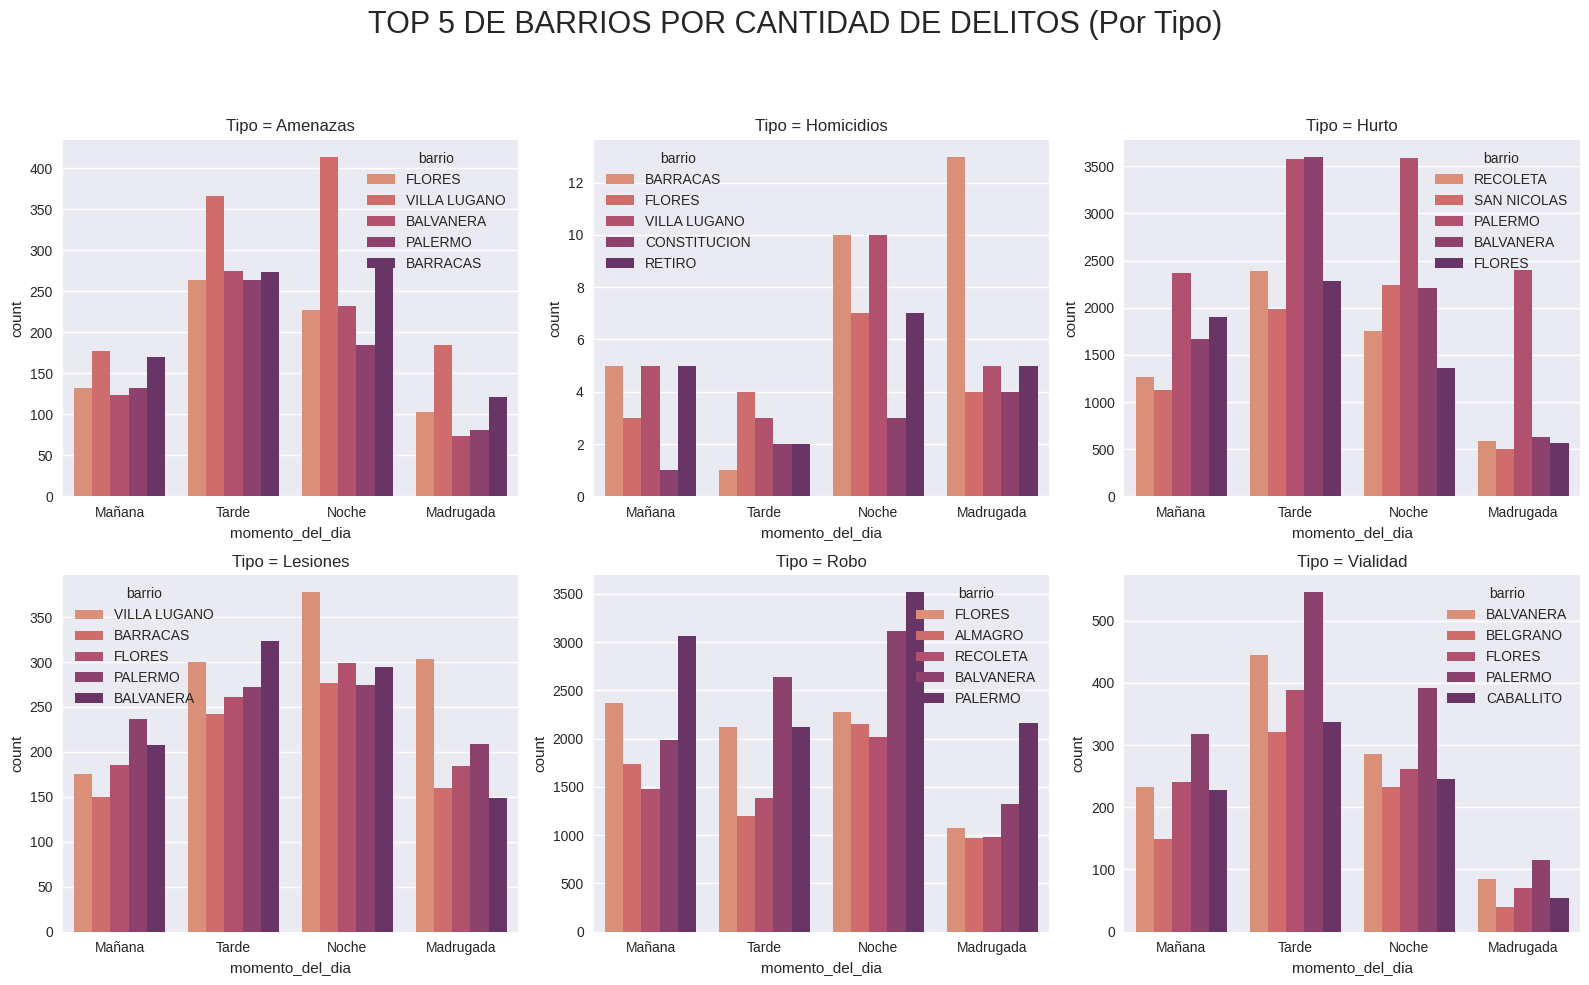

In [ ]:

# 1. Top 5 de barrios por tipo
top5_por_tipo = (
    df.groupby(['tipo','barrio'])
      .size()
      .reset_index(name='cantidad')
      .sort_values(['tipo','cantidad'], ascending=[True, False])
      .groupby('tipo')
      .head(5)
)

# 2. Diccionario tipo → lista de barrios del top 5
barrios_x_tipo = (
    top5_por_tipo.groupby('tipo')['barrio']
    .apply(list)
    .to_dict()
)

# 3. Loop por cada tipo de delito grafico independiente
tipos = top5_por_tipo['tipo'].unique()
num = len(tipos)

plt.figure(figsize=(16, 10))

for i, tipo in enumerate(tipos, 1):

    # Filtrar solo los registros de ese tipo y sus top 5 barrios
    df_t = df[(df['tipo'] == tipo) & (df['barrio'].isin(barrios_x_tipo[tipo]))]

    plt.subplot((num+2)//3, 3, i)

    sns.countplot(
        data=df_t,
        x="momento_del_dia",
        hue="barrio",
        palette="flare",
        dodge=True
    )

    plt.title(f"Tipo = {tipo}")
    plt.ylabel("count")
    plt.xlabel("momento_del_dia")

plt.suptitle(f"TOP 5 DE BARRIOS POR CANTIDAD DE DELITOS (Por Tipo)\n\n", fontsize=22)
plt.tight_layout()
plt.show()


In [ ]:
import folium
from folium.plugins import MarkerCluster

m = folium.Map(location=[-34.61, -58.44], zoom_start=12)
cluster = MarkerCluster().add_to(m)

for _, row in df.iterrows():
    folium.Marker(
        location=[row['latitud'], row['longitud']],
        popup=f"{row['barrio']} - {row['tipo']} - {row['fecha']}",
    ).add_to(cluster)



In [ ]:
m

Buffered data was truncated after reaching the output size limit.

#CONCLUSION

###Los analisis temporales mostraron que la frecuencia de delitos no se distribuye de manera uniforme, sino que presenta picos durante los dias laborales, lo que sugiere una relacion directa entre la actividad urbana y la delictiva. A nivel geo, se detectaron zonas con mayor densidad de incidentes, generalmente asociadas al transporte publico y zonas comerciales.